# circle grid detection

Membaca gambar dari: E:\test mini xray\preprocessing\output-test-cal\Image_20260227151903366_calibrate_raw_processed.tiff
Mengonversi gambar dari uint16 ke uint8...
Mencari grid dengan ukuran (27, 18)...
OpenCV findCirclesGrid gagal (internal error). Jumlah blob terdeteksi: 486 / Target: 486

[INFO] Mengaktifkan Algoritma Fallback Manual...
Jumlah titik sudah sesuai target. Merangkai koordinat grid secara manual...

=== BERHASIL: Pola Circle Grid ditemukan! ===
Informasi 5 titik pertama (X, Y) Pojok Kiri Atas:
  Titik 1: X=161.46, Y=150.34
  Titik 2: X=321.32, Y=152.89
  Titik 3: X=478.81, Y=151.95
  Titik 4: X=632.45, Y=150.87
  Titik 5: X=787.08, Y=149.56

[CEK TITIK TENGAH]
Baris ke-10, Kolom ke-14 -> Koordinat: X=1550.53, Y=1564.02


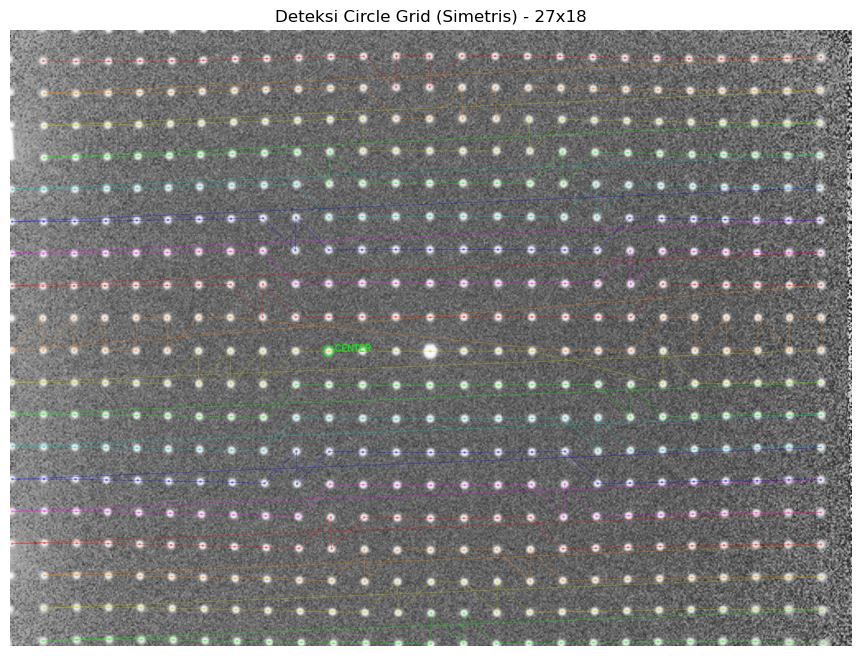

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def detect_circle_grid(image_path, grid_size=(27, 18), circle_diameter=40):
    # 1. Baca gambar
    print(f"Membaca gambar dari: {image_path}")
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if img is None:
        print("Error: Gambar tidak ditemukan atau format tidak didukung.")
        return

    if len(img.shape) == 2:
        gray = img
        img_display = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_display = img.copy()

    if gray.dtype != np.uint8:
        print(f"Mengonversi gambar dari {gray.dtype} ke uint8...")
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        img_display = cv2.normalize(
            img_display, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U
        )

    # 2. Atur Parameter SimpleBlobDetector
    params = cv2.SimpleBlobDetector_Params()
    params.filterByColor = True
    params.blobColor = 255

    radius = circle_diameter / 2
    expected_area = np.pi * (radius**2)

    params.filterByArea = True
    params.minArea = expected_area * 0.2
    params.maxArea = expected_area * 3.5

    params.filterByCircularity = True
    params.minCircularity = 0.7
    params.filterByConvexity = True
    params.minConvexity = 0.87
    params.filterByInertia = True
    params.minInertiaRatio = 0.5

    detector = cv2.SimpleBlobDetector_create(params)

    # 3. Deteksi pola Circle Grid via OpenCV
    print(f"Mencari grid dengan ukuran {grid_size}...")
    flags = cv2.CALIB_CB_SYMMETRIC_GRID | cv2.CALIB_CB_CLUSTERING
    ret, centers = cv2.findCirclesGrid(
        gray, grid_size, flags=flags, blobDetector=detector
    )

    # --- 3.1. FALLBACK: Pengurutan Manual jika OpenCV Terlalu Kaku ---
    keypoints = detector.detect(gray)

    if not ret:
        target_count = grid_size[0] * grid_size[1]
        print(
            f"OpenCV findCirclesGrid gagal (internal error). Jumlah blob terdeteksi: {len(keypoints)} / Target: {target_count}"
        )

        # Jika jumlah titik persis sama dengan jumlah target (27*18 = 486)
        if len(keypoints) == target_count:
            print("\n[INFO] Mengaktifkan Algoritma Fallback Manual...")
            print(
                "Jumlah titik sudah sesuai target. Merangkai koordinat grid secara manual..."
            )

            # Ambil hanya x dan y
            pts = [kp.pt for kp in keypoints]

            # 1. Urutkan seluruh titik berdasarkan Sumbu Y (Dari atas ke bawah)
            # Karena kemiringan gambar Anda sangat sedikit, ini sangat aman.
            pts.sort(key=lambda p: p[1])

            sorted_centers = []
            cols, rows = grid_size

            # 2. Potong per baris, lalu urutkan Sumbu X (Dari kiri ke kanan)
            for i in range(rows):
                row_pts = pts[i * cols : (i + 1) * cols]
                row_pts.sort(key=lambda p: p[0])
                for pt in row_pts:
                    sorted_centers.append([[pt[0], pt[1]]])

            # Ubah kembali formatnya sesuai standar output OpenCV (N, 1, 2)
            centers = np.array(sorted_centers, dtype=np.float32)
            ret = True  # Paksa status menjadi BERHASIL

    # 4. Tampilkan Hasil
    if ret:
        print("\n=== BERHASIL: Pola Circle Grid ditemukan! ===")
        print(f"Informasi 5 titik pertama (X, Y) Pojok Kiri Atas:")
        for i, pt in enumerate(centers[:5]):
            print(f"  Titik {i+1}: X={pt[0][0]:.2f}, Y={pt[0][1]:.2f}")

        # --- CEK TITIK TENGAH ---
        # Untuk grid 27x18, titik tengah (titik yang menyala terang) ada di baris 10 (index 9) dan kolom 14 (index 13)
        center_col = grid_size[0] // 2
        center_row = grid_size[1] // 2
        center_idx = center_row * grid_size[0] + center_col
        center_pt = centers[center_idx][0]

        print(f"\n[CEK TITIK TENGAH]")
        print(
            f"Baris ke-{center_row+1}, Kolom ke-{center_col+1} -> Koordinat: X={center_pt[0]:.2f}, Y={center_pt[1]:.2f}"
        )

        # Gambar garis yang menghubungkan titik-titik tersebut
        img_result = cv2.drawChessboardCorners(
            img_display.copy(), grid_size, centers, ret
        )

        # Gambar lingkaran ekstra (warna hijau) pada titik tengah untuk verifikasi visual
        cv2.circle(
            img_result, (int(center_pt[0]), int(center_pt[1])), 25, (0, 255, 0), 4
        )
        cv2.putText(
            img_result,
            "CENTER",
            (int(center_pt[0]) + 30, int(center_pt[1])),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.5,
            (0, 255, 0),
            3,
        )

        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
        plt.title(f"Deteksi Circle Grid (Simetris) - {grid_size[0]}x{grid_size[1]}")
        plt.axis("off")
        plt.show()
    else:
        print("\n=== GAGAL FATAL: Jumlah titik terdeteksi tidak mencapai target. ===")

        if len(keypoints) > 0:
            img_debug = cv2.drawKeypoints(
                img_display.copy(),
                keypoints,
                np.array([]),
                (0, 0, 255),
                cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
            )
            plt.figure(figsize=(12, 8))
            plt.imshow(cv2.cvtColor(img_debug, cv2.COLOR_BGR2RGB))
            plt.title(f"Debugging: Hanya {len(keypoints)} Titik Terdeteksi")
            plt.axis("off")
            plt.show()


# --- Bagian eksekusi (Cocok untuk 1 Cell di Jupyter Notebook / VS Code) ---

FILENAME = r"E:\test mini xray\preprocessing\output-test-cal\Image_20260227151903366_calibrate_raw_processed.tiff"
PATTERN_SIZE = (27, 18)

detect_circle_grid(FILENAME, grid_size=PATTERN_SIZE, circle_diameter=40)

# calculate scale

--- Menganalisis: E:\test mini xray\preprocessing\output-test-cal\Values-baris.csv ---

[DETAIL PUNCAK (Lingkaran Putih)]
  Puncak 1: X = 23.0 px, Intensitas (Y) = 63983.2
  Puncak 2: X = 92.0 px, Intensitas (Y) = 36517.9
  Puncak 3: X = 175.0 px, Intensitas (Y) = 64188.3
  Puncak 4: X = 225.0 px, Intensitas (Y) = 32323.9
  Puncak 5: X = 281.0 px, Intensitas (Y) = 40552.1
  Puncak 6: X = 335.0 px, Intensitas (Y) = 64599.0
  Puncak 7: X = 405.0 px, Intensitas (Y) = 40280.9
  Puncak 8: X = 486.0 px, Intensitas (Y) = 64061.3
  Puncak 9: X = 552.0 px, Intensitas (Y) = 36708.5
  Puncak 10: X = 639.0 px, Intensitas (Y) = 64087.0
  Puncak 11: X = 707.0 px, Intensitas (Y) = 36846.9
  Puncak 12: X = 799.0 px, Intensitas (Y) = 63736.5
  Puncak 13: X = 859.0 px, Intensitas (Y) = 41400.0
  Puncak 14: X = 951.0 px, Intensitas (Y) = 63780.2
  Puncak 15: X = 1010.0 px, Intensitas (Y) = 38000.7
  Puncak 16: X = 1102.0 px, Intensitas (Y) = 63259.6
  Puncak 17: X = 1174.0 px, Intensitas (Y) = 36369.6
  

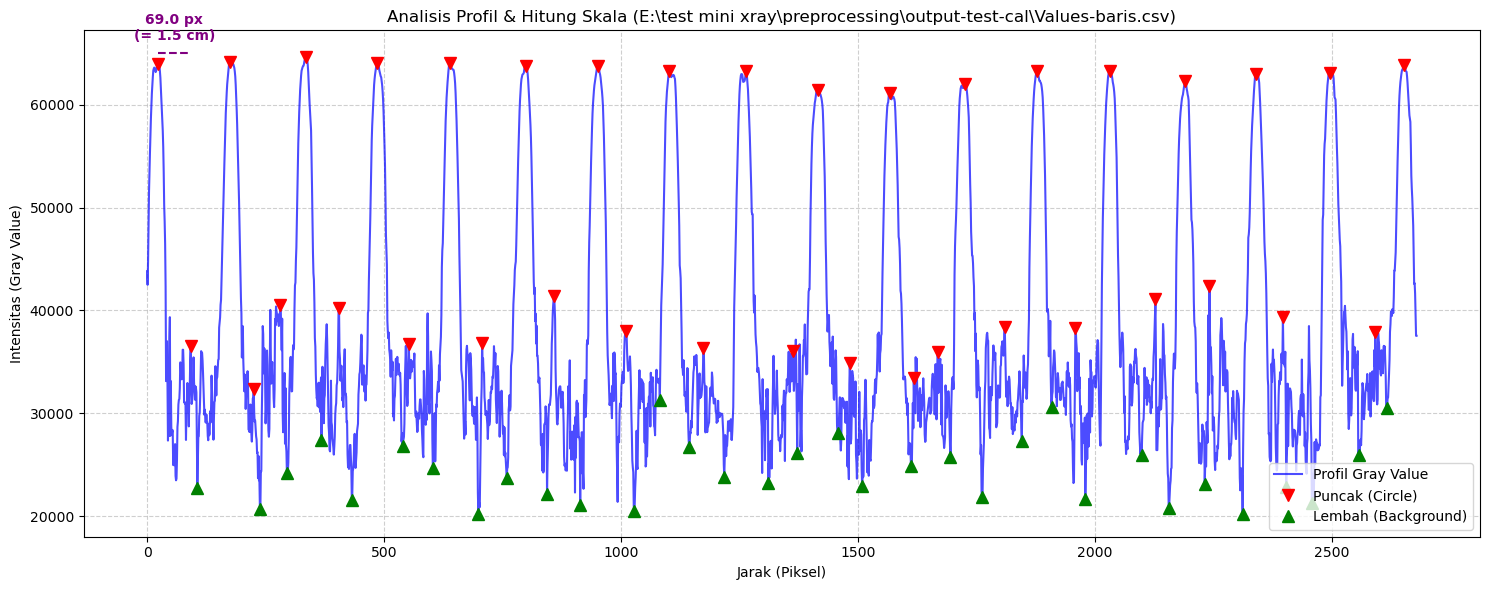

--- Menganalisis: E:\test mini xray\preprocessing\output-test-cal\Values-kolom.csv ---

[DETAIL PUNCAK (Lingkaran Putih)]
  Puncak 1: X = 23.0 px, Intensitas (Y) = 64501.0
  Puncak 2: X = 95.0 px, Intensitas (Y) = 42271.0
  Puncak 3: X = 184.0 px, Intensitas (Y) = 63026.0
  Puncak 4: X = 291.0 px, Intensitas (Y) = 35900.0
  Puncak 5: X = 344.0 px, Intensitas (Y) = 62300.0
  Puncak 6: X = 397.0 px, Intensitas (Y) = 32257.0
  Puncak 7: X = 455.0 px, Intensitas (Y) = 38985.0
  Puncak 8: X = 506.0 px, Intensitas (Y) = 62192.0
  Puncak 9: X = 559.0 px, Intensitas (Y) = 32403.0
  Puncak 10: X = 609.0 px, Intensitas (Y) = 30126.0
  Puncak 11: X = 660.0 px, Intensitas (Y) = 61119.0
  Puncak 12: X = 747.0 px, Intensitas (Y) = 37032.0
  Puncak 13: X = 815.0 px, Intensitas (Y) = 61529.0
  Puncak 14: X = 968.0 px, Intensitas (Y) = 62562.0
  Puncak 15: X = 1050.0 px, Intensitas (Y) = 38674.0
  Puncak 16: X = 1120.0 px, Intensitas (Y) = 63205.0
  Puncak 17: X = 1215.0 px, Intensitas (Y) = 35972.0
  

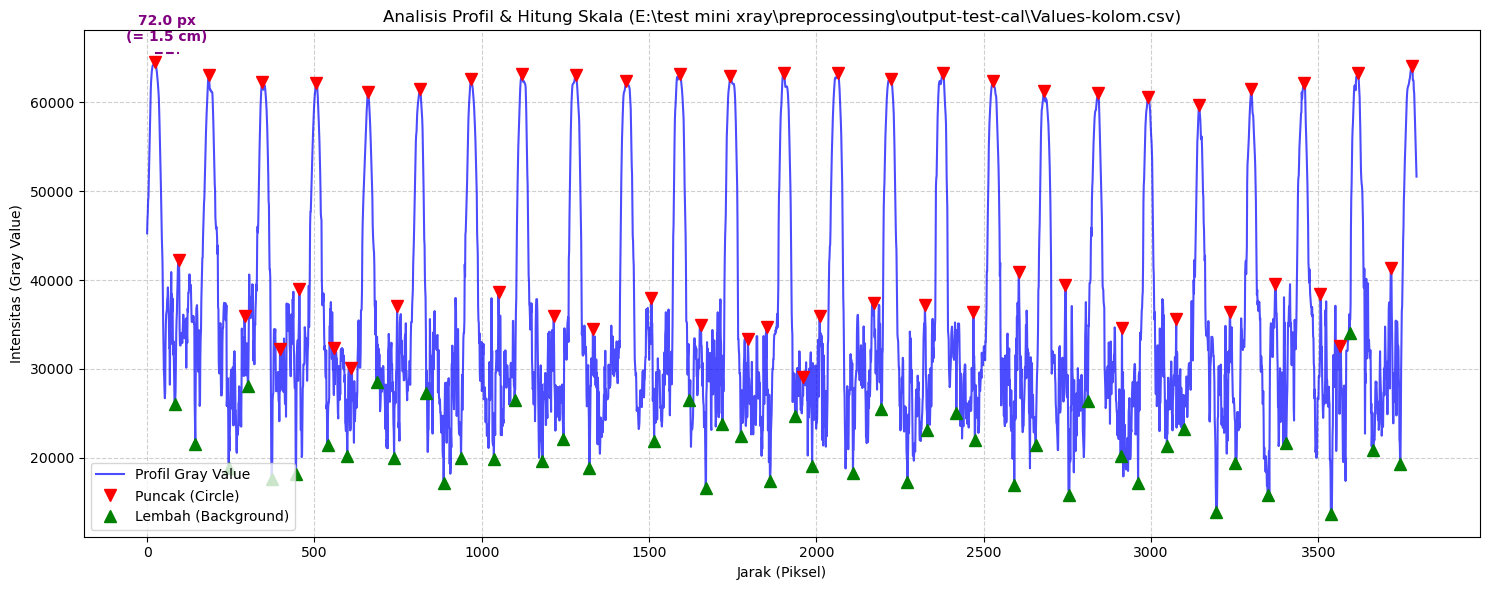

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


def analisis_profil_dan_skala(csv_path, jarak_fisik_cm=1.5):
    print(f"--- Menganalisis: {csv_path} ---")

    # 1. Baca data dari CSV
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File {csv_path} tidak ditemukan.")
        return

    # Ambil kolom X (Distance) dan Y (Gray Value)
    x = df["Distance_(pixels)"].values
    y = df["Gray_Value"].values

    # 2. Cari Puncak (Peaks) - merepresentasikan lingkaran putih
    # distance=50: Jarak minimum antar puncak diprediksi lebih dari 50 piksel
    # prominence=2000: Puncak harus cukup menonjol dibanding sekitarnya (menghindari noise)
    peaks, _ = find_peaks(y, distance=50, prominence=2000)

    # 3. Cari Lembah (Valleys) - merepresentasikan area gelap di antara lingkaran
    # Kita mencari puncak dari nilai negatifnya (-y)
    valleys, _ = find_peaks(-y, distance=50, prominence=2000)

    # 4. Hitung Jarak (Piksel) dan Skala
    x_peaks = x[peaks]

    if len(x_peaks) < 2:
        print("Puncak tidak cukup untuk menghitung jarak!")
        return

    # --- TAMBAHAN: Print detail Koordinat Puncak dan Lembah ---
    print("\n[DETAIL PUNCAK (Lingkaran Putih)]")
    for i, p in enumerate(peaks):
        print(f"  Puncak {i+1}: X = {x[p]:.1f} px, Intensitas (Y) = {y[p]:.1f}")

    print("\n[DETAIL LEMBAH (Background Gelap)]")
    for i, v in enumerate(valleys):
        print(f"  Lembah {i+1}: X = {x[v]:.1f} px, Intensitas (Y) = {y[v]:.1f}")
    print("-" * 40)

    # Hitung selisih jarak X (dalam piksel) antar puncak yang bersebelahan
    jarak_antar_puncak_pixel = np.diff(x_peaks)
    rata_rata_pixel = np.mean(jarak_antar_puncak_pixel)

    # Hitung konversi skala
    pixel_per_cm = rata_rata_pixel / jarak_fisik_cm
    cm_per_pixel = jarak_fisik_cm / rata_rata_pixel

    # Print Hasil
    print(f"\n[HASIL KALIBRASI SKALA]")
    print(f"Jumlah Puncak (Lingkaran) terdeteksi: {len(peaks)}")
    print(f"Jarak rata-rata antar puncak: {rata_rata_pixel:.2f} piksel")
    print(f"Skala referensi: {jarak_fisik_cm} cm = {rata_rata_pixel:.2f} piksel")
    print(f"Skala akhir: 1 cm = {pixel_per_cm:.2f} piksel")
    print(f"Skala akhir: 1 piksel = {cm_per_pixel:.4f} cm\n")

    # 5. Visualisasi (Plot)
    plt.figure(figsize=(15, 6))

    # Plot garis profil asli
    plt.plot(x, y, label="Profil Gray Value", color="blue", alpha=0.7)

    # Plot titik Puncak
    plt.plot(
        x[peaks], y[peaks], "v", color="red", markersize=8, label="Puncak (Circle)"
    )

    # Plot titik Lembah
    plt.plot(
        x[valleys],
        y[valleys],
        "^",
        color="green",
        markersize=8,
        label="Lembah (Background)",
    )

    # Beri anotasi jarak pada 2 puncak pertama sebagai contoh
    if len(x_peaks) >= 2:
        x1, y1 = x_peaks[0], y[peaks[0]]
        x2, y2 = x_peaks[1], y[peaks[1]]
        mid_x = (x1 + x2) / 2
        # Gambar garis horizontal penghubung antar dua puncak pertama
        plt.hlines(
            y=max(y1, y2) + 1000, xmin=x1, xmax=x2, color="purple", linestyle="--"
        )
        plt.text(
            mid_x,
            max(y1, y2) + 2000,
            f"{x2 - x1:.1f} px\n(= {jarak_fisik_cm} cm)",
            ha="center",
            va="bottom",
            color="purple",
            fontweight="bold",
        )

    plt.title(f"Analisis Profil & Hitung Skala ({csv_path})")
    plt.xlabel("Jarak (Piksel)")
    plt.ylabel("Intensitas (Gray Value)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


# --- Cara Menjalankan ---
if __name__ == "__main__":
    # Pastikan file CSV berada di folder yang sama dengan script ini,
    # atau sesuaikan path-nya.
    # PERBAIKAN: Gunakan huruf 'r' (raw string) di depan path Windows.

    # Analisis profil baris
    analisis_profil_dan_skala(
        r"E:\test mini xray\preprocessing\output-test-cal\Values-baris.csv",
        jarak_fisik_cm=1.5,
    )

    # Analisis profil kolom
    analisis_profil_dan_skala(
        r"E:\test mini xray\preprocessing\output-test-cal\Values-kolom.csv",
        jarak_fisik_cm=1.5,
    )